End to End Implementation fo Alex Net Arch from dataset to model Arch to Training to Evaluation

### Set Up

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import keras
import torch
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.src.legacy.preprocessing.image import ImageDataGenerator

In [3]:
cuda_is = torch.cuda.is_available()
print(cuda_is)

True


### The Dataset (3)

> Info : ImageNet dataset of over 15 million labeled high- resolution
images belonging to roughly 22,000 categories.

> Paper : ILSVRC uses a subset of ImageNet with roughly 1000 images in each of 1000 categories.
In all, there are roughly 1.2 million training images, 50,000 validation images, and 150,000 testing images.
Paper uses all these images

> Me : We use 50000 labeled high-resolution imaged of ImageNet validation dataset. Because its only 5gb. and trainset is 100+gb.
       I cant download and load it up >100gb images and train model for weeks in my laptop.
       So 50K of 5GB will do here fine for edu purpose.

> Paper : Down-sampled the images to a fixed resolution of 256 × 256. Given a rectangular image, we first rescaled the image such that the shorter side was of length 256, and then cropped out the central 256 × 256 patch from the resulting image. Then subtracting the mean activity over the training set from each pixel.

> Me : Implemented this data preprocessing as utils



In [4]:
dir = "ILSVRC2010_images"
print(f"Validation images: {len(os.listdir(os.path.join(dir, 'val')))}")

Validation images: 50000


### Data Augmentation (5.1)

From Paper :
The first form of data augmentation consists of generating image translations and horizontal reflections.
We do this by extracting random 224 × 224 patches (and their horizontal reflections) from the 256 × 256 images
and training our network on these extracted patches.


The second form of data augmentation consists of altering the intensities of the RGB channels in training images.
Specifically, we perform PCA on the set of RGB pixel values throughout the ImageNet training set.
To each training image, we add multiples of the found principal components, with magnitudes proportional to the corresponding
eigen values times a random variable drawn from a Gaussian with mean 0 and standard deviation 0.1.

Note : We Skipping PCA Augmentation

In [5]:
# preprocess utils
IMAGENET_MEAN = tf.constant([123.68, 116.779, 103.939], dtype=tf.float32) # Fixed commonly used mean, paper computed it for their e dataset might be different, dint publish those.

def resize_shorter_side(image):
    return tf.image.resize(image, size=(256, 256), preserve_aspect_ratio=True, antialias=True)

def center_crop(image):
    return tf.image.resize_with_crop_or_pad(image, target_height=256, target_width=256)

def subtract_mean(image):
    return tf.cast(image, tf.float32) - IMAGENET_MEAN

def random_crop(image):
    return tf.image.random_crop(image, size=(224, 224, 3))

def horizontal_flip(image):
    return tf.image.random_flip_left_right(image)

def augment(image):
    image = random_crop(image)
    image = horizontal_flip(image)
    return image

def preprocess(image):
    image = resize_shorter_side(image)
    image = center_crop(image)
    image = augment(image)
    image = subtract_mean(image)
    return image

In [6]:
label_path = os.path.join(dir, "ILSVRC2010_validation_ground_truth.txt")
df = pd.read_csv(label_path, header=None)
df.columns = pd.Index(["class"])
df["id"] = df.index+1
df["id"] = df["id"].astype(str).str.zfill(5)
df['class'] = df['class'].astype(str)
df

,class,id
0,78,00001
1,854,00002
2,435,00003
3,541,00004
4,973,00005
...,...,...
49995,467,49996
49996,646,49997
49997,68,49998
49998,93,49999


In [7]:
prefix = "ILSVRC2010_val_000"
df['id'] = prefix+df['id'].astype(str) + '.JPEG'


In [8]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["class"])

In [9]:
datagen = ImageDataGenerator(preprocessing_function=preprocess)

train_data = datagen.flow_from_dataframe(dataframe=train_df, directory=os.path.join(dir, "val"), x_col="id", y_col="class",
                                         target_size=(224, 224), batch_size=128, class_mode="categorical", shuffle=True)

val_data = datagen.flow_from_dataframe(dataframe=val_df, directory=os.path.join(dir, "val"), x_col="id", y_col="class",
                                       target_size=(224, 224), batch_size=128, class_mode="categorical", shuffle=False)

Found 40000 validated image filenames belonging to 1000 classes.
Found 10000 validated image filenames belonging to 1000 classes.


In [10]:
images, labels = next(train_data)

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
print("Class indices mapping:", train_data.class_indices)

Images batch shape: (128, 224, 224, 3)
Labels batch shape: (128, 1000)
Class indices mapping: {'1': 0, '10': 1, '100': 2, '1000': 3, '101': 4, '102': 5, '103': 6, '104': 7, '105': 8, '106': 9, '107': 10, '108': 11, '109': 12, '11': 13, '110': 14, '111': 15, '112': 16, '113': 17, '114': 18, '115': 19, '116': 20, '117': 21, '118': 22, '119': 23, '12': 24, '120': 25, '121': 26, '122': 27, '123': 28, '124': 29, '125': 30, '126': 31, '127': 32, '128': 33, '129': 34, '13': 35, '130': 36, '131': 37, '132': 38, '133': 39, '134': 40, '135': 41, '136': 42, '137': 43, '138': 44, '139': 45, '14': 46, '140': 47, '141': 48, '142': 49, '143': 50, '144': 51, '145': 52, '146': 53, '147': 54, '148': 55, '149': 56, '15': 57, '150': 58, '151': 59, '152': 60, '153': 61, '154': 62, '155': 63, '156': 64, '157': 65, '158': 66, '159': 67, '16': 68, '160': 69, '161': 70, '162': 71, '163': 72, '164': 73, '165': 74, '166': 75, '167': 76, '168': 77, '169': 78, '17': 79, '170': 80, '171': 81, '172': 82, '173': 83, 

In [11]:
labels[0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [12]:
np.argmax(labels[0])

np.int64(142)

In [13]:
images[0]

array([[[ 80.60905  , 126.221    , 148.29144  ],
        [ 79.07     , 126.47491  , 147.81491  ],
        [ 78.480156 , 126.31866  , 147.47116  ],
        ...,
        [131.0075   , 137.90851  , 150.7485   ],
        [130.2497   , 137.1507   , 149.99069  ],
        [129.945    , 136.84601  , 149.686    ]],

       [[ 81.26531  , 126.221    , 148.03363  ],
        [ 80.15203  , 126.67803  , 147.70554  ],
        [ 79.8825   , 126.7835   , 147.6235   ],
        ...,
        [131.0075   , 137.90851  , 150.7485   ],
        [130.1325   , 137.03351  , 149.8735   ],
        [129.32     , 136.22101  , 149.061    ]],

       [[ 81.429375 , 127.12336  , 148.55319  ],
        [ 81.21844  , 127.9085   , 148.85397  ],
        [ 81.195    , 127.49444  , 148.63522  ],
        ...,
        [130.57004  , 137.47104  , 150.31104  ],
        [129.85907  , 136.76007  , 149.60007  ],
        [129.7575   , 136.65851  , 149.4985   ]],

       ...,

       [[-23.125328 , -13.353172 ,   6.799225 ],
        [-2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..151.061].


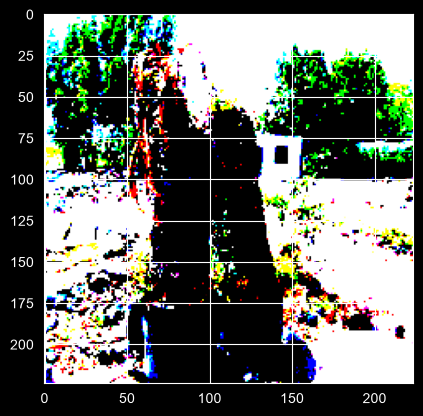

In [14]:
plt.imshow(images[0])
plt.show()

### Model Architecture (4)

In [15]:
# 4.3. Local response normalization
def LocalResponseNormalization(name):
    return keras.layers.Lambda(lambda x: tf.nn.local_response_normalization(x, depth_radius=2, bias=2.0, alpha=1e-4, beta=0.75),
        output_shape=lambda input_shape: input_shape, name=name)

In [16]:
inputs = keras.Input(shape=(224, 224, 3))

x = keras.layers.ZeroPadding2D(2)(inputs) # Padding for original conv size, embedded implementation in paper code, Can be skipped.

# Layer1
x = keras.layers.Conv2D(filters=96, kernel_size=11, strides=4, padding="valid", activation="relu", name="conv1",
                        kernel_regularizer=keras.regularizers.l2(5e-4))(x) # Weight Decay using l2 From (6). ReLU from (5.1
x = LocalResponseNormalization(name="lrn1")(x)
x = keras.layers.MaxPooling2D(pool_size=3, strides=2, name="pool1")(x)

# Layer2
x = keras.layers.Conv2D(filters=256, kernel_size=5, strides=1, padding="same", activation="relu", name="conv2",
                        kernel_regularizer=keras.regularizers.l2(5e-4))(x)
x = LocalResponseNormalization(name="lrn2")(x)
x = keras.layers.MaxPooling2D(pool_size=3, strides=2, name="pool2")(x)

# Layer3
x = keras.layers.Conv2D(filters=384, kernel_size=3, strides=1, padding="same", activation="relu", name="conv3",
                        kernel_regularizer=keras.regularizers.l2(5e-4))(x)

# Layer4
x = keras.layers.Conv2D(filters=384, kernel_size=3, strides=1, padding="same", activation="relu", name="conv4",
                        kernel_regularizer=keras.regularizers.l2(5e-4))(x)

# Layer5
x = keras.layers.Conv2D(filters=256, kernel_size=3, strides=1, padding="same", activation="relu", name="conv5",
                        kernel_regularizer=keras.regularizers.l2(5e-4))(x)
x = keras.layers.MaxPooling2D(pool_size=3, strides=2, name="pool5")(x)

# Layer 6
x = keras.layers.Flatten(name="flatten")(x)
x = keras.layers.Dense(4096, activation="relu", name="dense1", kernel_regularizer=keras.regularizers.l2(5e-4))(x)
x = keras.layers.Dropout(0.5)(x) # From 5.2

# Layer 7
x = keras.layers.Dense(4096, activation="relu", name="dense2", kernel_regularizer=keras.regularizers.l2(5e-4))(x)
x = keras.layers.Dropout(0.5)(x) # From 5.2

# Layer 8
outputs = keras.layers.Dense(1000, activation="softmax", name="dense3", kernel_regularizer=keras.regularizers.l2(5e-4))(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 228, 228, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn1 (Lambda)                   │ (None, 55, 55, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn2 (Lambda)                   │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,378,344 (237.95 MB)

 Trainable params: 62,378,344 (237.95 MB)

 Non-trainable params: 0 (0.00 B)

Model Arch Diagram from Paper :

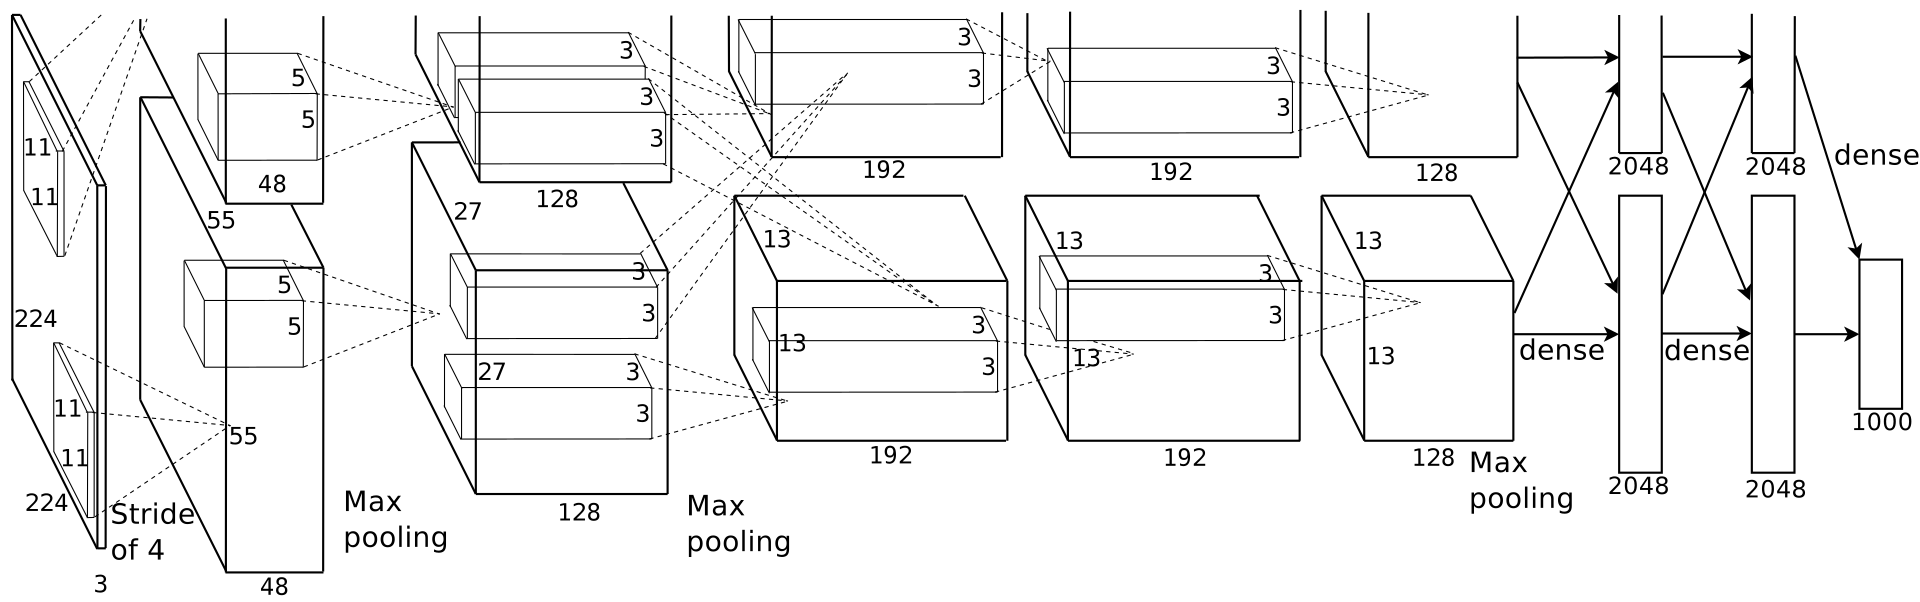

### Training/Learning (6)

From Paper :

We trained our models using stochastic gradient descent with a batch size of 128 examples, momentum of 0.9, and weight decay of 0.0005.


We initialized the weights in each layer from a zero-mean Gaussian distribution with standard deviation 0.01.
We initialized the neuron biases in the second, fourth, and fifth convolutional layers, as well as in the fully connected hidden
layers, with the constant 1.
This initialization accelerates the early stages of learning by providing the ReLUs with positive inputs.
We initialized the neuron biases in the remaining layers with the constant 0

Note : We leave all Weight Initialization to keras library default

In [17]:
# Optimizer
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)

In [18]:
model.compile(optimizer=optimizer, loss="categorical_crossentropy",
              metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=5, name="top5")])

In [19]:
# LR Scheduler
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5, verbose=1)

In [20]:
checkpoint = keras.callbacks.ModelCheckpoint("alexnet_prash.keras", monitor="val_accuracy", save_best_only=True)

In [21]:
# Training
history = model.fit(train_data, validation_data=val_data, epochs=90, callbacks=[reduce_lr, checkpoint])

RuntimeError: Unable to automatically build the model. Please build it yourself before calling fit/evaluate/predict. A model is 'built' when its variables have been created and its `self.built` attribute is True. Usually, calling the model on a batch of data is the right way to build it.
Exception encountered:
'Exception encountered when calling Lambda.call().

[1mcan't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.[0m

Arguments received by Lambda.call():
  • inputs=torch.Tensor(shape=torch.Size([128, 55, 55, 96]), dtype=float32)
  • mask=None
  • training=False'